In [1]:
import pandas as pd
import duckdb as db
import matplotlib.pyplot as plt

from datetime import datetime
from prophet import Prophet

from prophet.plot import plot_plotly, plot_components_plotly  

/home/jose/dashboard/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
df = pd.read_csv('../../../data/TrafficPerTerritory.csv')

In [23]:
df['Month'] = pd.to_datetime(df['Month'], format="%Y-%m-%d")

In [24]:
df_plot = df.loc[(df['AirServiceId'] == 0) & (df['AircraftMovementId'] == 2) & (df['IslandId'] == 0) & (df['StopoverTerritoryId'] == 9)].copy(deep=True)

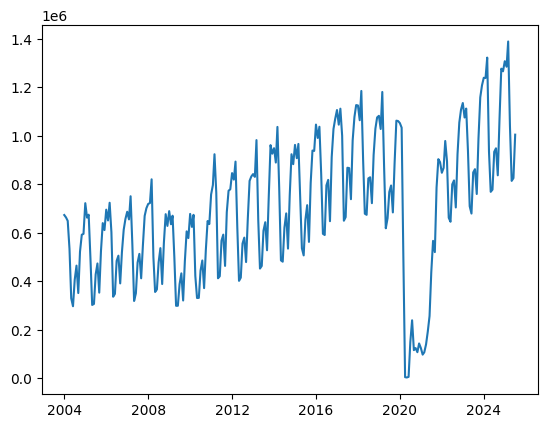

In [25]:
plt.plot(df_plot['Month'], df_plot['Passengers'])

## Testing

As we can see in the plot above, COVID created an outlier period in the data. To handle this we will use the Prophet model and set those values to None, this way the model will handle the missing data automatically by interpolating through the period withouth letting it affect the model's understanding of normal patterns

In [26]:
# Total Passengers that arrive to Gran Canaria per month
df_prophet = df.loc[(df['AirServiceId'] == 0) & (df['AircraftMovementId'] == 2) & (df['IslandId'] == 6)].copy(deep=True)

In [27]:
s = df_prophet.groupby(['Month']).sum()

In [28]:
s

,IslandId,StopoverTerritoryId,AircraftMovementId,AirServiceId,Passengers,Operations,Goods,Mail
Month,,,,,,,,
2004-01-01,30,42,10,0,73027,1470,117336,4102
2004-02-01,30,42,10,0,75485,1339,137275,4022
2004-03-01,30,42,10,0,81473,1438,155723,5175
2004-04-01,30,42,10,0,85712,1546,126441,5721
2004-05-01,30,42,10,0,69713,1450,114683,4001
...,...,...,...,...,...,...,...,...
2025-03-01,30,42,10,0,139843,2146,23402,0
2025-04-01,30,42,10,0,128904,1881,21788,0
2025-05-01,30,42,10,0,117374,1835,20053,0


In [29]:
df_prophet = s[['Passengers']].copy(deep=True)


df_prophet.reset_index(inplace=True)

df_prophet.rename({'Month': 'ds', 'Passengers': 'y'}, axis=1, inplace=True)

In [30]:
df_prophet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 259 entries, 0 to 258
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      259 non-null    datetime64[ns]
 1   y       259 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 4.2 KB


In [31]:
df_prophet.loc[(df_prophet['ds'] >= '2020-03-01') & (df_prophet['ds'] < '2022-06-01'), 'y'] = None

In [32]:
df_prophet.loc[(df_prophet['ds'] >= '2020-03-01') & (df_prophet['ds'] < '2022-06-01')]

,ds,y
194,2020-03-01,NaN
195,2020-04-01,NaN
196,2020-05-01,NaN
197,2020-06-01,NaN
198,2020-07-01,NaN
199,2020-08-01,NaN
200,2020-09-01,NaN
201,2020-10-01,NaN
202,2020-11-01,NaN
203,2020-12-01,NaN


In [33]:
m = Prophet()
m.fit(df_prophet)

22:30:37 - cmdstanpy - INFO - Chain [1] start processing
22:30:37 - cmdstanpy - INFO - Chain [1] done processing


In [34]:
future = m.make_future_dataframe(periods=12, freq='MS') 

In [35]:
forecast = m.predict(future)

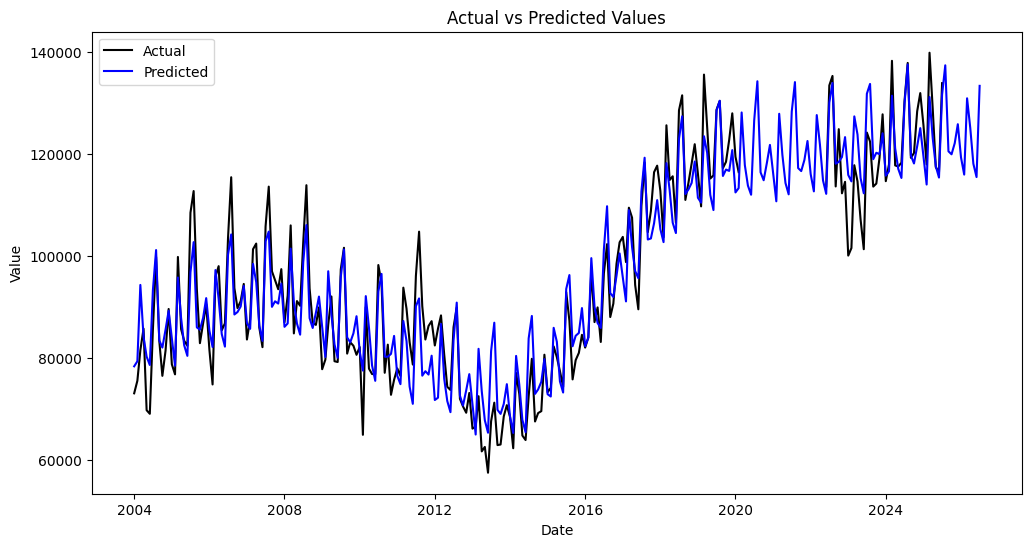

In [36]:
# Plot actual vs predicted
plt.figure(figsize=(12, 6))
plt.plot(df_prophet['ds'], df_prophet['y'], label='Actual', color='black')
plt.plot(forecast['ds'], forecast['yhat'], label='Predicted', color='blue')
plt.legend()
plt.title('Actual vs Predicted Values')
plt.xlabel('Date')
plt.ylabel('Value')
plt.show()

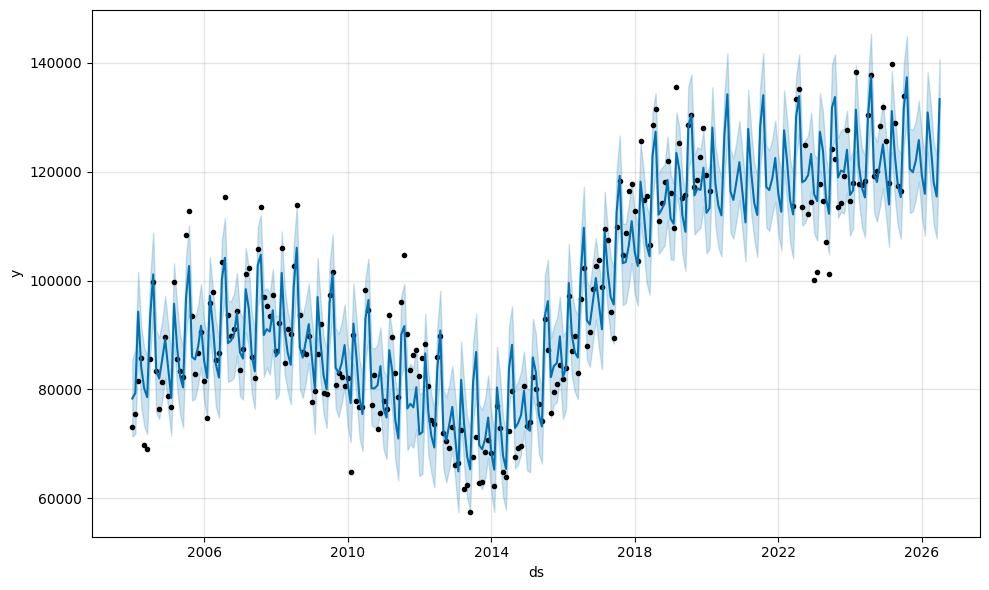

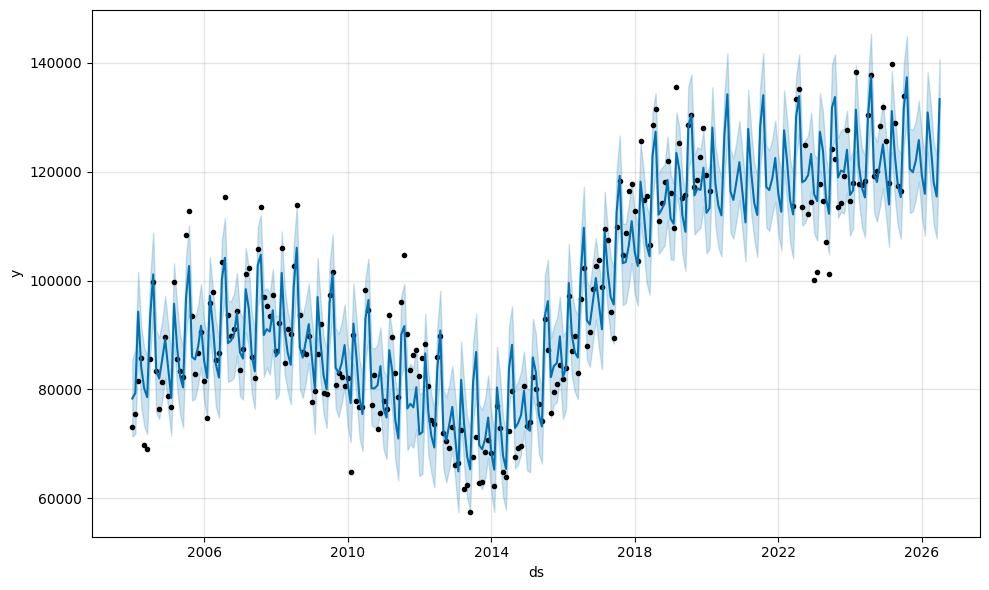

In [37]:
m.plot(forecast)

## Pipeline

In [61]:
df = pd.read_csv('../../../data/TrafficPerTerritory.csv')
df['Month'] = pd.to_datetime(df['Month'], format="%Y-%m-%d")

In [62]:
islands_id = [0, 1, 2, 3, 4, 5, 6, 7]
observed_values = ["Passengers"]
predictions_for_each_island = []

for island_id in islands_id:
    for observed_value in observed_values:
        df_prophet = df.loc[(df['AirServiceId'] == 0) & (df['AircraftMovementId'] == 2) & 
                                (df['IslandId'] == island_id)].copy(deep=True)
        df_prophet = df_prophet.groupby('Month').sum()[[observed_value]].copy(deep=True)
        df_prophet.reset_index(inplace=True)
        df_prophet.rename({'Month': 'ds', observed_value: 'y'}, axis=1, inplace=True)
        df_prophet.loc[(df_prophet['ds'] >= '2020-03-01') & (df_prophet['ds'] < '2022-06-01'), 'y'] = None
        m = Prophet()
        m.fit(df_prophet)
        future = m.make_future_dataframe(periods=12, freq='MS') 
        predictions_for_each_island.append((island_id, m.predict(future)[['ds', 'yhat_lower', 'yhat', 'yhat_upper']], observed_value, df_prophet))

17:39:41 - cmdstanpy - INFO - Chain [1] start processing
17:39:41 - cmdstanpy - INFO - Chain [1] done processing
17:39:41 - cmdstanpy - INFO - Chain [1] start processing
17:39:41 - cmdstanpy - INFO - Chain [1] done processing
17:39:41 - cmdstanpy - INFO - Chain [1] start processing
17:39:41 - cmdstanpy - INFO - Chain [1] done processing
17:39:41 - cmdstanpy - INFO - Chain [1] start processing
17:39:41 - cmdstanpy - INFO - Chain [1] done processing
17:39:41 - cmdstanpy - INFO - Chain [1] start processing
17:39:41 - cmdstanpy - INFO - Chain [1] done processing
17:39:41 - cmdstanpy - INFO - Chain [1] start processing
17:39:41 - cmdstanpy - INFO - Chain [1] done processing
17:39:41 - cmdstanpy - INFO - Chain [1] start processing
17:39:41 - cmdstanpy - INFO - Chain [1] done processing
17:39:41 - cmdstanpy - INFO - Chain [1] start processing
17:39:41 - cmdstanpy - INFO - Chain [1] done processing


In [63]:
final = pd.DataFrame(columns=["ds", "yhat_lower", "yhat", "yhat_upper", "IslandId"])

In [64]:
for pr in predictions_for_each_island:
    pr[1]['IslandId'] = pr[0]
    final = pd.concat([final, pr[1]])
    #pr[1].to_csv(f'../../../data/predictions/{island_name}{pr[2]}Predictions.csv', index=False)
    #pr[3].to_csv(f'../../../data/predictions/real_values/{island_name}{pr[2]}Real.csv', index=False)


/tmp/ipykernel_6670/2260639734.py:3: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final = pd.concat([final, pr[1]])


In [65]:
tpt = db.read_csv('../../../data/TrafficPerTerritory.csv')
ter = db.read_csv('../../../data/Territory.csv')

In [66]:
final = db.sql(f"SELECT TerritoryName AS Island, ds AS Month, RealPassengers, yhat_lower, yhat, yhat_upper \
         FROM (SELECT IslandId, Month, SUM(Passengers) AS RealPassengers \
                FROM tpt WHERE AirServiceId = 0 AND AircraftMovementId = 2 \
                        GROUP BY IslandId, Month ORDER BY IslandId, Month) t \
         RIGHT JOIN final f ON t.IslandId = f.IslandId AND t.Month = f.ds INNER JOIN ter ON ter.TerritoryId = f.IslandId \
         ORDER BY 1,2").df()

In [67]:
final.to_csv(f'../../../data/predictions/Predictions.csv', index=False)